In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy  as np
import ClassicalModel as CM
import torch
import models_parallel as models
import random


def fun(x):
    return np.heaviside(x,0)
def fun2(x):
    return np.sin(np.pi*x)

input_eval  = np.linspace(-1,1,200)
y_true      = fun(input_eval)
y_true2     = fun2(input_eval)

# Figure 2 from paper

Observation: the plote take ~2 min in my computer

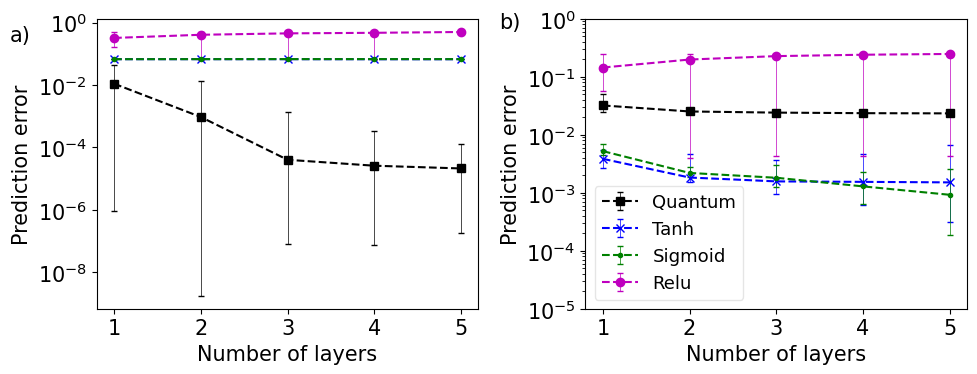

In [29]:
activation_fuction = [torch.nn.Tanh(),torch.nn.Sigmoid(),torch.nn.ReLU()]
name_function = ["Tanh","Sigmoid","Relu"]
color =  ['b--x','g--.','m--o']

plt.rcParams.update({'font.size': 15})
fig, (ax1, ax2) = plt.subplots(ncols=2,figsize=(10,4))
plt.rcParams.update({'font.size': 15})
# Classico
for i in range(len(activation_fuction)):
    
    erro = []
    for N_of_layer in range(1,6):
        ram = []
        for manualSeed in range(1,100):
                    
            np.random.seed(manualSeed)
            random.seed(manualSeed)
            torch.manual_seed(manualSeed)
            if torch.cuda.is_available():
                torch.cuda.manual_seed(manualSeed)
                torch.cuda.manual_seed_all(manualSeed)
                torch.backends.cudnn.deterministic = True
                
            modelo  = CM.ClassicalModel(
                epochs      = 1000,
                neuronio    = [1]*N_of_layer,
                activation  = activation_fuction[i],
                lr          = 0.01
            )
            modelo.load_checkpoint(checkpoint_path=f"Data/classical/sino_comparing_by_layer/seed{manualSeed}_layer{N_of_layer}_{name_function[i]}")
            predict = modelo.evaluate(input_eval.reshape(-1,1)).detach().numpy()
            ram.append( np.mean(((predict-y_true2.reshape(-1,1))**2)))
        erro.append(ram)
    erro    = np.array(erro)  
    minimo  = erro.min(axis=1)
    media   = erro.mean(axis=1)
    maximo  = erro.max(axis=1)
    ax1.errorbar(
        range(1,6), 
        media,
        yerr=[abs(media-minimo),abs(maximo-media)],
        elinewidth=0.5,
        fmt=f'{color[i]}', 
        label=f'{name_function[i]}',
        capsize=2)

# Quântico
erro = []
for j in range(1,6):
    ram  = []
    for i in range(1,100):
        quantum = models.Train(D= 30,number_of_layers=j)
        try:
            quantum.load_checkpoint(checkpoint_path=f'Data/quantum/{j}layer/model_sin{i}.pth')
            predict = quantum.evaluate(input = input_eval)
            ram.append(np.mean((predict-y_true2)**2))
        except FileNotFoundError:
            ram.append(0)
            print(f"Arquivo {j}layer / model_sin{i} não encontrado ")
            continue
    erro.append(ram) 
    
erro    = np.array(erro)  
minimo  = erro.min(axis=1)
media   = erro.mean(axis=1)
maximo  = erro.max(axis=1)
ax1.errorbar(
    range(1,6), 
    media,
    yerr=[abs(media-minimo),abs(maximo-media)],
    elinewidth=0.5,
    fmt='ks--', 
    label='Quantum',
    capsize=2)
# ax1.legend()
#ax1.set_title("Seno")
ax1.set_xlabel('Number of layers')
ax1.set_yscale("log")
ax1.set_ylabel('Prediction error')   
ax1.set_xticks([1, 2, 3, 4, 5])

###################################################################################################


# Quântico
erro = []
for j in range(1,6):
    ram  = []
    for i in range(1,100):
        quantum = models.Train(D= 30,number_of_layers=j)
        try:
            quantum.load_checkpoint(checkpoint_path=f'Data/quantum/{j}layer/model_Heaviside{i}.pth')
            predict = quantum.evaluate(input = input_eval)
            ram.append(np.mean((predict-y_true)**2))
        except FileNotFoundError:
            print(f"Arquivo {j}layer / model_Heaviside{i} não encontrado ")
            ram.append(0)
            continue
    erro.append(ram)    

erro    = np.array(erro)  
minimo  = erro.min(axis=1)
media   = erro.mean(axis=1)
maximo  = erro.max(axis=1)
ax2.errorbar(range(1,6), media,yerr=[abs(media-minimo),abs(maximo-media)],
            elinewidth=0.5,fmt='ks--', label='Quantum',capsize=2)


# Classico
for i in range(len(activation_fuction)):
    
    erro = []
    for N_of_layer in range(1,6):
        ram = []
        for manualSeed in range(1,100):
                    
            np.random.seed(manualSeed)
            random.seed(manualSeed)
            torch.manual_seed(manualSeed)
            if torch.cuda.is_available():
                torch.cuda.manual_seed(manualSeed)
                torch.cuda.manual_seed_all(manualSeed)
                torch.backends.cudnn.deterministic = True
                
            modelo  = CM.ClassicalModel(
                epochs      = 1000,
                neuronio    = [1]*N_of_layer,
                activation  = activation_fuction[i],
                lr          = 0.01
            )
            modelo.load_checkpoint(checkpoint_path=f"Data/classical/Heaviside_comparing_by_layer/seed{manualSeed}_layer{N_of_layer}_{name_function[i]}")
            predict = modelo.evaluate(input_eval.reshape(-1,1)).detach().numpy()
            ram.append( np.mean((predict-y_true.reshape(-1,1))**2))
        erro.append(ram)
    erro    = np.array(erro)  
    minimo  = erro.min(axis=1)
    #print(minimo)
    media   = erro.mean(axis=1)
    maximo  = erro.max(axis=1)
    ax2.errorbar(
        range(1,6), 
        media,
        yerr=[abs(media-minimo),abs(maximo-media)],
        elinewidth=0.5,
        fmt=f'{color[i]}', 
        label=f'{name_function[i]}',
        capsize=2)
    
ax2.set_xlabel('Number of layers')
ax2.set_yscale("log")
ax2.set_ylabel('Prediction error')
ax2.set_xticks([1, 2, 3, 4, 5])
ax2.set_ylim(10**(-5),1)  # eixo y de ax2 vai de 0 a 20

fig.tight_layout()

plt.legend(fontsize=13,framealpha=0.5,loc=3)
ax1.text(-0.2, 0.25, 'a)', fontsize=15)
ax2.text(-0.2, 0.7, 'b)', fontsize=15)
#plt.savefig("seno_heavi_camada.pdf",dpi=1000)

plt.show()

# Figure 4 from paper

First we need generatar all classical combination 

In [30]:
from itertools import product
activation_fuction = [torch.nn.Tanh(),torch.nn.Sigmoid(),torch.nn.ReLU()]
name_function = ["Tanh","Sigmoid","Relu"]
def all_neuro(N_layer,numberofneuro):
    todas_combinacoes = []
    for n in range(1, N_layer + 1):
        todas_combinacoes.extend(product(range(1, numberofneuro + 1), repeat=n))

    todas_combinacoes_util=[]
    N_of_parameter = []
    index_all_combinatino = []
    for indice in range(len(todas_combinacoes)):
        modelo  = CM.ClassicalModel(
                epochs      = 1000,
                neuronio    = todas_combinacoes[indice],
                activation  = activation_fuction[0],
                lr          = 0.01) 
        if modelo.Number_of_parameter() in (5,10,15,20,25):
            todas_combinacoes_util.append( todas_combinacoes[indice])
            N_of_parameter.append(modelo.Number_of_parameter())
            index_all_combinatino.append(indice)
            
    # dt_Parametre = [ 
    #                 [3],
    #                 [1, 4],
    #                 [1, 2, 2],
    #                 [1, 1, 1, 2, 1],
    #                 [4, 1, 2],
    #                 [3, 1, 3],
    #                 [1, 1, 5],
    #                 [2, 2, 1, 2],
    #                 [8],
    #                 [5,8],
    #                 [1, 2, 1, 5],
    #                 [1, 2, 2, 1, 3],  
    #                 [1, 1, 2, 2, 2, 1],    
    #                 [4, 1, 2, 3], 
    #                 [2, 2, 3, 2],
    #                 [1, 1, 3, 1, 5],
    #                 [1, 1, 2, 2, 2, 1, 2],
    #                 [3, 2, 5],
    #                 [2, 5, 1, 3],
    #                 [5, 1, 3, 2, 1],
    #                 [2, 1, 2, 2, 1, 1, 1, 2, 1, 1]]
    # for indice in range(len(dt_Parametre)):
    #     modelo  = CM.ClassicalModel(
    #             step_size   = 500,
    #             epochs      = 1000,
    #             neuronio    = todas_combinacoes[indice],
    #             activation  = activation_fuction[0],
    #             lr          = 0.01) 
    #     if modelo.Number_of_parameter() in (5,10,15,20,25):
    #         todas_combinacoes_util.append( dt_Parametre[indice])
    return todas_combinacoes_util,N_of_parameter,index_all_combinatino
combination,number_combination_parameter,index_combination = all_neuro(3,10)      

Observation: the plote take ~3 min in my computer

/tmp/ipykernel_13777/1860368671.py:60: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=13,framealpha=0.5)


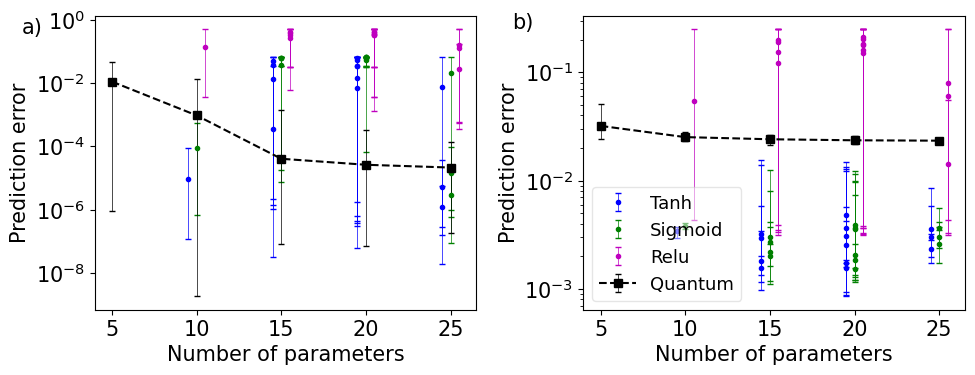

In [41]:
fig, (ax1, ax2) = plt.subplots(ncols=2,figsize=(10,4))
plt.rcParams.update({'font.size': 15})
color =  ['b','g','m']
# Classical
index =0
shift =-0.5
for index in range(len(name_function)):
    erro =[] 
    for indice in range(len(combination)):
        ram = []
        for manualSeed in range(1,100):      
            modelo  = CM.ClassicalModel(
                #step_size   = 500,
                epochs      = 10000,
                neuronio    = combination[indice],
                activation  = activation_fuction[index],
                lr          = 0.01)
            modelo.load_checkpoint(checkpoint_path=f"Data/classical/sino_comparing_by_parameter/seed{manualSeed}_indice{indice}_{name_function[index]}")
            predict = modelo.evaluate(input_eval.reshape(-1,1)).detach().numpy()
            ram.append( np.mean((predict-y_true2.reshape(-1,1))**2))
        erro.append(ram)

    erro    = np.array(erro)  
    minimo  = erro.min(axis=1)
    media   = erro.mean(axis=1)
    maximo  = erro.max(axis=1)
    ax1.errorbar(
        np.array(number_combination_parameter)+shift, 
        media,
        yerr=[abs(media-minimo),abs(maximo-media)],
        elinewidth=0.5,
        fmt=f'{color[index]}.', 
        label=f'{name_function[index]}',
        capsize=2)   
    shift+=0.5 

# Quântico
erro = []
for j in range(1,6):
    ram  = []
    for i in range(1,100):
        quantum = models.Train(D= 30,number_of_layers=j)
        quantum.load_checkpoint(checkpoint_path=f'Data/quantum/{j}layer/model_sin{i}.pth')
        predict = quantum.evaluate(input= input_eval)
        ram.append(np.mean((predict-y_true2)**2))
    erro.append(ram) 
    
erro    = np.array(erro)  
minimo  = erro.min(axis=1)
media   = erro.mean(axis=1)
maximo  = erro.max(axis=1)
ax1.errorbar(
    [5,10,15,20,25], 
    media,
    yerr=[abs(media-minimo),abs(maximo-media)],
    elinewidth=0.5,
    fmt='ks--', 
    label='Quantum',
    capsize=2)
plt.legend(fontsize=13,framealpha=0.5)
ax1.set_xlabel('Number of parameters')
ax1.set_yscale("log")
ax1.set_ylabel('Prediction error')  
#ax1.set_title("Sen(x)")
############################################################################################

index =0
shift =-0.5
for index in range(len(name_function)):

    erro =[] 
    for indice in range(len(combination)):
        ram = []
        for manualSeed in range(1,100):
            
            modelo  = CM.ClassicalModel(
                #step_size   = 500,
                epochs      = 10000,
                neuronio    = combination[indice],
                activation  = activation_fuction[index],
                lr          = 0.01)
            modelo.load_checkpoint(checkpoint_path=f"Data/classical/Heaviside_comparing_by_parameter/seed{manualSeed}_indice{indice}_{name_function[index]}")
            predict = modelo.evaluate(input_eval.reshape(-1,1)).detach().numpy()
            ram.append( np.mean((predict-y_true.reshape(-1,1))**2))
        erro.append(ram)

    erro    = np.array(erro)  
    minimo  = erro.min(axis=1)
    media   = erro.mean(axis=1)
    maximo  = erro.max(axis=1)
    ax2.errorbar(
        np.array(number_combination_parameter)+shift, 
        media,
        yerr=[abs(media-minimo),abs(maximo-media)],
        elinewidth=0.5,
        fmt=f'{color[index]}.', 
        label=f'{name_function[index]}',
        capsize=2)
    ax2.set_yscale("log")
    ax2.set_xticks([0,5,10,15,20,25])
    ax2.set_ylabel('Prediction error')
    
    shift+=0.5    
    
# Quântico
erro = []
for j in range(1,6):
    ram  = []
    for i in range(1,100):
        quantum = models.Train(D= 30,number_of_layers=j)
        quantum.load_checkpoint(checkpoint_path=f'Data/quantum/{j}layer/model_Heaviside{i}.pth')
        predict = quantum.evaluate(input = input_eval)
        ram.append(np.mean((predict-y_true)**2))
    erro.append(ram)    

erro    = np.array(erro)  
minimo  = erro.min(axis=1)
media   = erro.mean(axis=1)
maximo  = erro.max(axis=1)
ax2.errorbar([5,10,15,20,25], media,yerr=[abs(media-minimo),abs(maximo-media)],
            elinewidth=0.5,fmt='ks--', label='Quantum',capsize=2)
#ax2.set_title("Heaviside(x)")  
ax2.set_xlabel('Number of parameters')
fig.tight_layout()
plt.legend(fontsize=13,framealpha=0.5,loc=3)
# plt.savefig("plote_param.pdf",dpi=1000)
ax1.text(-0.3, 0.35, 'a)', fontsize=15)
ax2.text(-0.2, 0.25, 'b)', fontsize=15)
plt.show()
